# Project 3: Mental Health & Threat Level Analysis(DATA 101)
#### Name: Brisa Menautt

### A) Introduction: 

The objective of this analysis was to investigate the relationship between behavioral health indicators and law enforcement outcomes. Specifically, I am trying to answer the research question:
#### "How does the presence of signs of mental illness affect the reported threat level in fatal police shootings?" 
By understanding how these variables interact with each other, we can gain insights into whether or not individuals with documented mental health issues are perceived or reported differently during high-stress police encounters. The data used for this study is the Fatal Force dataset created by the Washington Post, which tracks every fatal shooting by a police officer in the US since January 1st, 2015. This dataset is appropriate for this research because it contains detailed situational variables, including the threat_type (point, move, attack, shoot, etc.), was_mental_illness_related, and other contributing factors such as "age", "gender", "race", and whether the individual was armed or fleeing. This analysis employs Logistic Regression and Principal Component Analysis (PCA) to determine if these situational features can accurately predict a high-threat classification.

### B) Supervised/Unsupervised Learning
For this analysis, I implemented Logistic Regression, a supervised learning algorithm used for binary classification. The goal is to predict the target (whether the incident was classified as an "attack" threat level) based on situational features, including signs of mental illness, age, gender, race, and fleeing status.

#### Original Feature Set: 

First, the model is trained on the full set of processed features to establish a baseline accuracy of 85.72%.

#### Dimensionality Reduction (PCA): 
Second, I applied Principal Component Analysis (PCA) to transform the feature set. PCA is used here to reduce the number of variables while retaining the most significant patterns in the data. I targeted a 90% explained variance ratio to ensure the model retained the vast majority of the original data's information while removing noise. As shown in the Scree Plot below, the cumulative explained variance reaches the 90% threshold at exactly 27 principal components. By reducing the feature set from the original count to the PCA-transformed set, the model's accuracy actually increased from 85.72% to 86.08%. This suggests that PCA successfully removed noise and redundant information, allowing the Logistic Regression model to focus on the most impactful predictors of threat level.

### C) Conclusion and Future Directions
The analysis successfully demonstrated that situational factors and mental health indicators can predict an "attack" threat level with approximately 86% accuracy. A key finding was that the PCA-transformed model performed slightly better than the original model, indicating that many situational variables in police shooting incidents are highly correlated. By simplifying these variables, we found a more robust pattern for predicting how threat levels are reported.
These results are meaningful because they highlight the consistency in how incidents are categorized, but also show that a large portion of the variance can be explained by a few key "principal components." Future research should incorporate more granular data, such as officer experience levels or department-specific training protocols, to see if these hidden patterns vary across different law enforcement agencies.

### D) References
Dataset: Washington Post. (2026). Fatal Force: Police shootings database. https://github.com/washingtonpost/data-police-shootings.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [48]:
#Loading data and basic cleaning
df = pd.read_csv('fatal-police-shootings-data.csv')
df = df[['threat_type', 'was_mental_illness_related', 'armed_with', 'age', 'gender', 'race', 'flee_status']].dropna()

In [49]:
# Converting armed_with to binary is_armed feature
df['is_armed'] = df['armed_with'].apply(lambda x: 0 if 'unarmed' in str(x).lower() else 1)
print(df['is_armed'].value_counts())

is_armed
1    6573
0     464
Name: count, dtype: int64


In [50]:
df['target'] = (df['threat_type'] == 'attack').astype(int)
X = pd.get_dummies(df.drop(['threat_type', 'target'], axis=1), drop_first=True)
y = df['target']

In [51]:
#Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [52]:
#Original model
original_model = LogisticRegression().fit(X_train, y_train)
print(f"Original Accuracy: {accuracy_score(y_test, original_model.predict(X_test)):.2%}")

Original Accuracy: 85.72%


In [53]:
#PCA model
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
model_pca = LogisticRegression().fit(X_train_pca, y_train)
print(f"PCA: Accuracy: {accuracy_score(y_test, model_pca.predict(X_test_pca)):.2%}")

PCA: Accuracy: 86.08%


To capture 90% of the variance, we need 27 components.


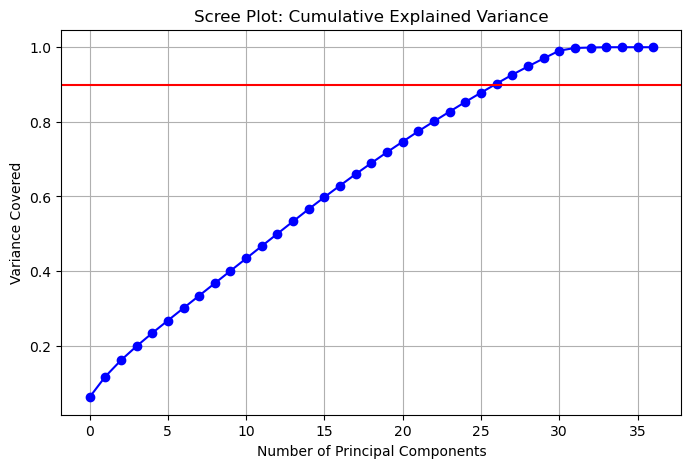

In [68]:
pca_check = PCA().fit(X_train)
cumulative_variance = np.cumsum(pca_check.explained_variance_ratio_)

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"To capture 90% of the variance, we need {n_components_90} components.")

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o', linestyle='-', color='b')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Covered')
plt.grid()
plt.show()

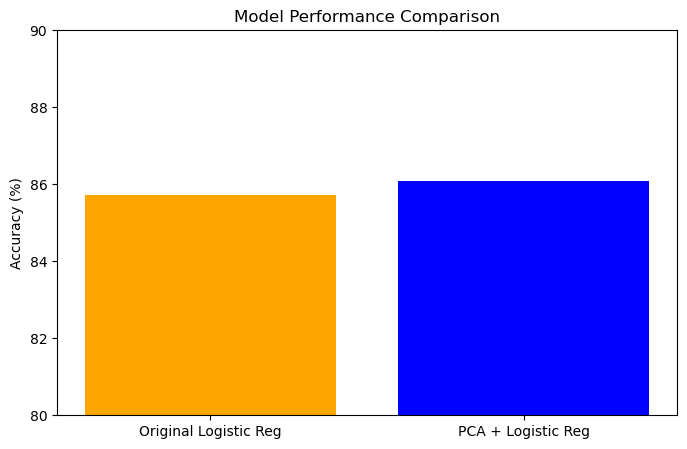

In [73]:
import matplotlib.pyplot as plt

# Comparison Data
models = ['Original Logistic Reg', 'PCA + Logistic Reg']
accuracies = [85.72, 86.08]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['orange', 'blue'])
plt.ylim(80, 90)
plt.ylabel('Accuracy (%)')
plt.title('Model Performance Comparison')
plt.show()